# HBB: whole vs. sum of parts (AlphaGenome)

Does AlphaGenome predict an individual's combination of HBB-window variants to differ from the naive sum of each variant's own single-variant effect (Atlas)? `SCALE` below picks which run this notebook reads - `"dev"` (10 samples, small window) while developing/iterating, `"full"` (the full-scale run) otherwise.

## imports

In [1]:
import dataclasses

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.visualization import plot_transcripts

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
sns.set_context("notebook")

# HBB/K562 total RNA-seq is the track used throughout this notebook.
TRACK_NAME = "EFO:0002067 total RNA-seq"
TRACK_STRAND = "."           # for filtering the Atlas-only singles/MAF tables
# summarize_whole_vs_sum_parts.py joins on track_name alone (not also track_strand):
# for this track, the personalized-sequence model only ever emits strand="-" (HBB is
# minus-strand, and match_gene_strand=True there keeps only gene-strand-consistent
# tracks) while Atlas's own K562 catalog only ever exposes strand="." - a metadata
# labeling mismatch between the two systems for this one assay, not two genuinely
# distinct tracks (Atlas's singles table never has >1 strand per track_name).
TRACK_STRAND_COMBINED = "-"  # for filtering whole_vs_sum_parts (combined side's own strand)
HBB_GENE_ID = "ENSG00000244734"
CHROMOSOME = "chr11"


## data

In [2]:
SCALE = "full"  # "dev" while developing; "full" for the full-scale run

ROOT = ".."
UNIQUE_VARIANT_SCORES = f"{ROOT}/results/03-analysis/hbb_k562/unique_variant_scores.{SCALE}.parquet"
UNIQUE_VARIANT_MAF = f"{ROOT}/results/03-analysis/hbb_k562/unique_variant_gnomad_maf.{SCALE}.parquet"
WHOLE_VS_SUM_PARTS = f"{ROOT}/results/03-analysis/hbb_k562/whole_vs_sum_parts.{SCALE}.parquet"
GTF_PARQUET = f"{ROOT}/data/raw/GENCODE/release_46/gencode.v46.annotation.gtf.parquet"

WINDOW = {"dev": (5221202, 5237586), "full": (4705106, 5753682)}[SCALE]
INTERVAL = genome.Interval(CHROMOSOME, *WINDOW)

con = duckdb.connect()

# Atlas single-variant HBB/K562 effects, already restricted (see
# subset_hbb_k562_unique_variant_scores_{dev,full}) to just the SNVs actually carried by
# the 1000 Genomes samples in scope - never the raw Atlas saturation set.
singles = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [UNIQUE_VARIANT_SCORES, TRACK_NAME, TRACK_STRAND],
).df()
singles["position"] = singles["variant"].str.split(":").str[1].astype(int)
singles["alt"] = singles["variant"].str.split(">").str[1]

# gnomAD v3.1.1 allele frequency / MAF for that same unique-variant set.
maf = con.execute("SELECT * FROM read_parquet(?)", [UNIQUE_VARIANT_MAF]).df()
singles_maf = singles.merge(maf, on="variant", how="inner")
singles_maf["log10_maf"] = np.log10(singles_maf["gnomad_maf"])

# Per-sample combinatorial (whole_score) vs. sum-of-independent-effects (sum_parts_score).
combined = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [WHOLE_VS_SUM_PARTS, TRACK_NAME, TRACK_STRAND_COMBINED],
).df()

len(singles), len(singles_maf), len(combined)


/users/diasfrazer/manglada/miniforge3/envs/wihttsoip/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(47194, 47194, 1842)

In [3]:
# Gene annotation for the window - one (longest) transcript per protein-coding gene, so
# every gene overlapping the window is guaranteed a representative model to draw (MANE
# Select tags are missing for many genes in this GTF).
gtf = pd.read_parquet(GTF_PARQUET)
gtf_coding = gene_annotation.filter_protein_coding(gtf)
gtf_coding = gene_annotation.filter_to_longest_transcript(gtf_coding)

transcript_extractor = transcript_utils.TranscriptExtractor(gtf_coding)
transcripts = transcript_extractor.extract(INTERVAL)
print(f"{len(transcripts)} protein-coding genes in window")


/users/diasfrazer/manglada/projects/wihttsoip/src/alphagenome/src/alphagenome/data/transcript.py:661: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


42 protein-coding genes in window


## figures

### Single-variant effects across the HBB window

Top: each point is one SNV's predicted effect on HBB expression (K562 total RNA-seq). Bottom: gene annotation for the window, all genes in gray except HBB in orange.

/tmp/28402528/ipykernel_3281180/3020421793.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


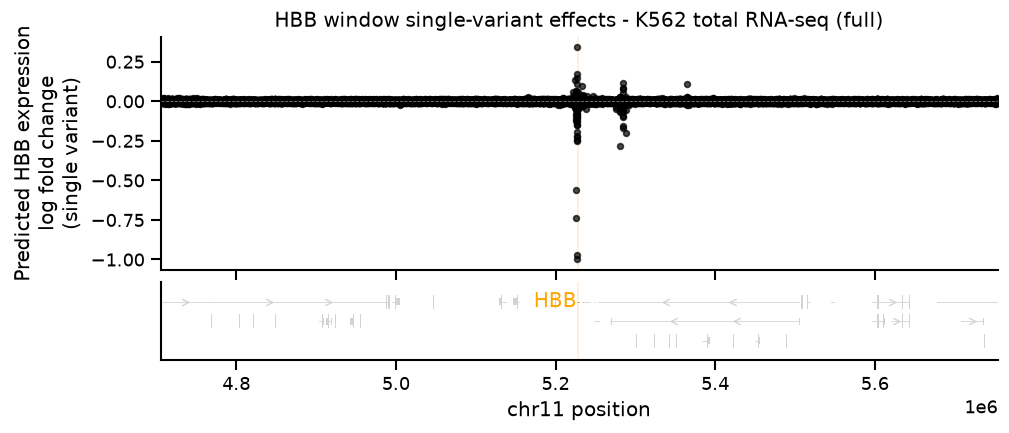

In [4]:
fig, (ax_scatter, ax_genes) = plt.subplots(
    2, 1, figsize=(9, 3.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
)

ax_scatter.scatter(singles["position"], singles["score"], s=12, color="black", alpha=0.7)
ax_scatter.axhline(0, color="gray", lw=0.5, ls="--")
ax_scatter.set_ylabel("Predicted HBB expression\nlog fold change\n(single variant)")
ax_scatter.set_title(f"HBB window single-variant effects - K562 total RNA-seq ({SCALE})")

GRAY_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="lightgray", utr5_color="lightgray", utr3_color="lightgray",
    first_noncoding_exon_color="lightgray", label_color="gray",
)
ORANGE_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="orange", utr5_color="orange", utr3_color="orange",
    first_noncoding_exon_color="orange", label_color="orange",
)

# HBB (~4kb) is a sliver of the full 1,048,576bp window (~0.4% of its width) - drawing its
# transcript model in orange is barely visible at that scale (single-pixel-wide box, easily
# lost among 40+ other genes), so also shade its full genomic span across BOTH axes with a
# translucent band - visible regardless of window/zoom scale, unlike the transcript model.
hbb_transcripts = [
    t for t in transcripts if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID
]
if hbb_transcripts:
    hbb_start = min(t.transcript_interval.start for t in hbb_transcripts)
    hbb_end = max(t.transcript_interval.end for t in hbb_transcripts)
    for ax in (ax_scatter, ax_genes):
        ax.axvspan(hbb_start, hbb_end, color="orange", alpha=0.15, zorder=0, lw=0)

# _get_placement_heights (alphagenome's own row-packing layout) is computed once across
# ALL transcripts together, then each is drawn (via alphagenome's own draw_transcript) with
# gray/orange picked per gene - keeps correct shared vertical stacking while still coloring
# HBB distinctly, which plot_transcripts() itself can't do in a single call (one style/call).
# HBB is drawn last (highest zorder) and with a taller cds_height so its sliver of a
# transcript model isn't occluded/lost among the other genes' boxes either.
heights = plot_transcripts._get_placement_heights(transcripts, extend_fraction=1.0)
non_hbb = [t for t in transcripts if t not in hbb_transcripts]
for t in non_hbb:
    plot_transcripts.draw_transcript(
        ax=ax_genes, transcript=t, interval=INTERVAL, y=heights[t.transcript_id],
        cds_height=GRAY_STYLE.cds_height, utr_height=GRAY_STYLE.utr_height,
        cds_color=GRAY_STYLE.cds_color, utr5_color=GRAY_STYLE.utr5_color,
        utr3_color=GRAY_STYLE.utr3_color,
        first_noncoding_exon_color=GRAY_STYLE.first_noncoding_exon_color,
        label_color=GRAY_STYLE.label_color, label=None, zorder=1,
    )
for t in hbb_transcripts:
    plot_transcripts.draw_transcript(
        ax=ax_genes, transcript=t, interval=INTERVAL, y=heights[t.transcript_id],
        cds_height=ORANGE_STYLE.cds_height * 1.5, utr_height=ORANGE_STYLE.utr_height * 1.5,
        cds_color=ORANGE_STYLE.cds_color, utr5_color=ORANGE_STYLE.utr5_color,
        utr3_color=ORANGE_STYLE.utr3_color,
        first_noncoding_exon_color=ORANGE_STYLE.first_noncoding_exon_color,
        label_color=ORANGE_STYLE.label_color, label="HBB", zorder=2,
    )

ax_genes.set_xlim(INTERVAL.start, INTERVAL.end)
ax_genes.set_ylim(min(heights.values()) - 1, max(heights.values()) + 1)
ax_genes.set_yticks([])
ax_genes.set_xlabel(f"{CHROMOSOME} position")
fig.tight_layout()


### Single-variant effects vs. gnomAD minor allele frequency

Only variants in the subsetted unique-variant set (i.e. actually carried by the 1000 Genomes samples in scope), not every variant Atlas scores. Hue = ALT allele.

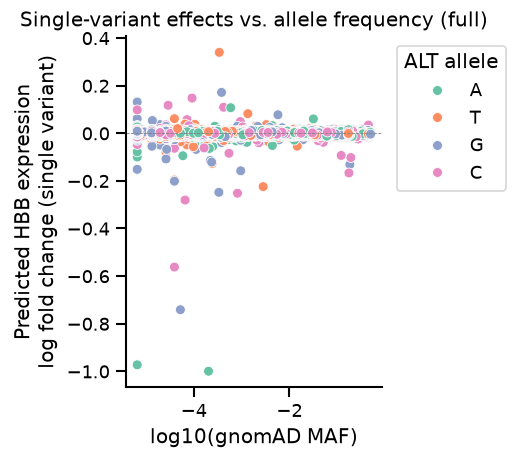

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.scatterplot(
    data=singles_maf, x="log10_maf", y="score", hue="alt",
    palette="Set2", s=35, ax=ax,
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("log10(gnomAD MAF)")
ax.set_ylabel("Predicted HBB expression\nlog fold change (single variant)")
ax.set_title(f"Single-variant effects vs. allele frequency ({SCALE})")
ax.legend(title="ALT allele", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()


### Combinatorial vs. sum-of-independent-effects

Each point is one individual: their combinatorial (multi-variant) predicted HBB expression change vs. the sum of their carried variants' own independent single-variant effects - the additive/no-epistasis null.

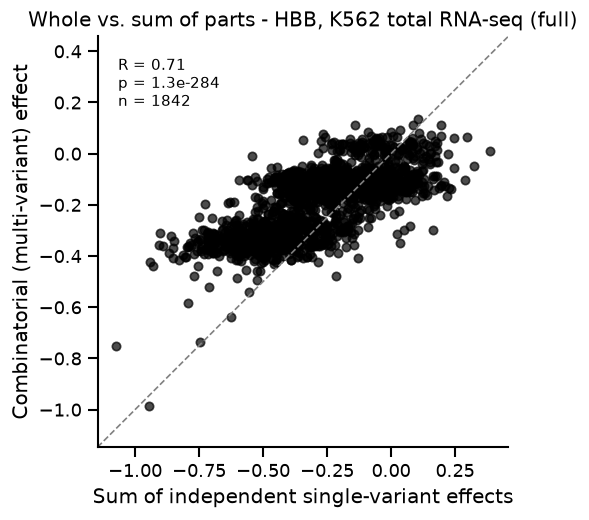

In [6]:
x = combined["sum_parts_score"].to_numpy()
y = combined["whole_score"].to_numpy()
r, p = stats.pearsonr(x, y)
n = len(combined)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x, y, s=25, color="black", alpha=0.7)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Sum of independent single-variant effects")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title(f"Whole vs. sum of parts - HBB, K562 total RNA-seq ({SCALE})")
ax.text(
    0.05, 0.95, f"R = {r:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
fig.tight_layout()


### Diagnostics: whole − sum-of-parts vs. variant burden, allele frequency, distance to TSS, and clustering

The combinatorial-vs-sum-of-parts scatter above shows a few horizontal clusters and a skew toward the sum overstating the whole. To see what's driving that: the distribution of `whole - sum_parts` directly, then `|whole - sum_parts|` (deviation *magnitude*, regardless of direction) against four per-sample summaries of the variants a sample carries - how many, their median allele frequency, their median distance to the HBB TSS, and how spatially clustered they are (median distance to each variant's nearest neighbor) - hued by variant count, since burden likely confounds the others. Each panel reports Pearson r/p/n.

Also: does the combinatorial effect track the *strongest* single-variant effect a sample carries better than it tracks the *sum* of all of them? And for the individual samples with the most extreme whole-vs-sum deviation in either direction, what do their actual carried variants (and each one's own single-variant score) look like?

In [7]:
# Per-sample summaries of the variants each sample carries, used in the diagnostics
# below: median gnomAD MAF, median distance to the HBB TSS, median nearest-neighbor
# distance between carried variants (a clustering/spread measure - sort positions,
# then for each variant take the smaller of its gap to the previous/next variant, and
# summarize with the median across the sample's variants), and the single strongest
# (largest |score|) carried variant's own Atlas effect (as an alternative to summing
# all of them). variant_id is 0-based (see summarize_whole_vs_sum_parts.py's
# docstring); converted to 1-based here to match maf's/singles' variant strings, same
# as that script does internally.
hbb_transcript = hbb_transcripts[0]
tss = (
    hbb_transcript.transcript_interval.end
    if hbb_transcript.strand == "-"
    else hbb_transcript.transcript_interval.start
)

maf_by_variant = maf.set_index("variant")["gnomad_maf"]
score_by_variant = singles.set_index("variant")["score"]


def _variant_positions(variant_id):
    if not variant_id:
        return [], []
    positions, variants_1based = [], []
    for v in variant_id.split(";"):
        chrom, pos, ref_alt = v.split(":")
        pos_1based = int(pos) + 1
        positions.append(pos_1based)
        variants_1based.append(f"{chrom}:{pos_1based}:{ref_alt}")
    return positions, variants_1based


def _median_nearest_neighbor_dist(positions):
    if len(positions) < 2:
        return np.nan
    sorted_pos = np.sort(np.array(positions, dtype=float))
    gaps = np.diff(sorted_pos)
    left = np.concatenate(([np.inf], gaps))
    right = np.concatenate((gaps, [np.inf]))
    return np.median(np.minimum(left, right))


def _sample_summary(variant_id):
    positions, variants_1based = _variant_positions(variant_id)
    if not variants_1based:
        return pd.Series({
            "median_log10_maf": np.nan, "median_log10_dist_tss": np.nan,
            "median_log10_nn_dist": np.nan, "strongest_single_score": np.nan,
        })
    positions = np.array(positions)
    mafs = np.array([maf_by_variant.get(v, np.nan) for v in variants_1based])
    scores = np.array([score_by_variant.get(v, np.nan) for v in variants_1based])
    dist_tss = np.abs(positions - tss)
    dist_tss = np.where(dist_tss == 0, 1, dist_tss)
    nn_dist = _median_nearest_neighbor_dist(positions)
    strongest_idx = np.nanargmax(np.abs(scores)) if np.any(~np.isnan(scores)) else None
    return pd.Series({
        "median_log10_maf": np.log10(np.nanmedian(mafs)),
        "median_log10_dist_tss": np.log10(np.median(dist_tss)),
        "median_log10_nn_dist": np.log10(nn_dist) if nn_dist > 0 else np.nan,
        "strongest_single_score": scores[strongest_idx] if strongest_idx is not None else np.nan,
    })

combined = combined.join(combined["variant_id"].apply(_sample_summary))
combined["diff"] = combined["whole_score"] - combined["sum_parts_score"]
combined["abs_diff"] = combined["diff"].abs()
combined[[
    "n_variants", "diff", "median_log10_maf", "median_log10_dist_tss",
    "median_log10_nn_dist", "strongest_single_score",
]].describe()

,n_variants,diff,median_log10_maf,median_log10_dist_tss,median_log10_nn_dist,strongest_single_score
count,1842.000000,1842.000000,1842.000000,1842.000000,1842.000000,1842.000000
mean,2828.314332,0.085615,-0.589171,5.333996,1.856014,-0.133613
std,374.780646,0.158675,0.045518,0.049029,0.042474,0.056963
min,1556.000000,-0.462740,-0.770431,5.213318,1.778151,-0.972624
25%,2570.000000,-0.024877,-0.615932,5.290081,1.819544,-0.166646
50%,2844.500000,0.090457,-0.576821,5.332403,1.857332,-0.131089
75%,3090.750000,0.192868,-0.554471,5.368293,1.886491,-0.131089
max,3837.000000,0.589701,-0.523561,5.498783,2.004321,0.339997


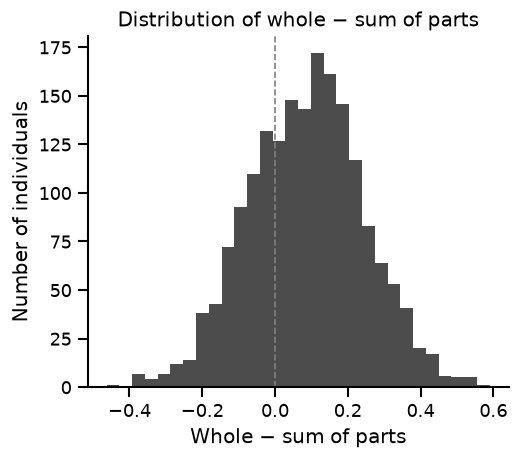

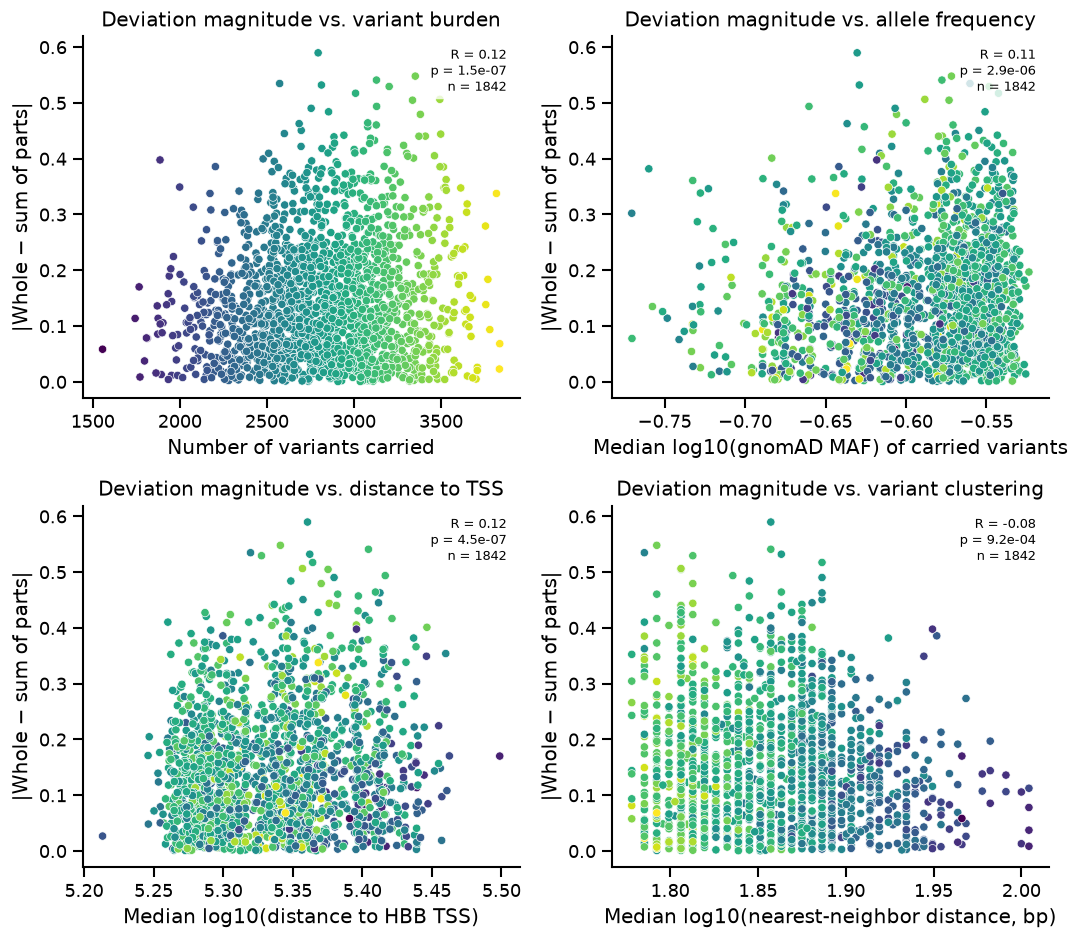

In [8]:
def _annotate_corr(ax, x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    r, p = stats.pearsonr(x[mask], y[mask])
    ax.text(
        0.97, 0.97, f"R = {r:.2f}\np = {p:.1e}\nn = {mask.sum()}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.8),
    )


fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hist(combined["diff"], bins=30, color="black", alpha=0.7)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Whole − sum of parts")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of whole − sum of parts")
fig.tight_layout()


panels = [
    ("n_variants", "Number of variants carried", "Deviation magnitude vs. variant burden"),
    ("median_log10_maf", "Median log10(gnomAD MAF) of carried variants", "Deviation magnitude vs. allele frequency"),
    ("median_log10_dist_tss", "Median log10(distance to HBB TSS)", "Deviation magnitude vs. distance to TSS"),
    ("median_log10_nn_dist", "Median log10(nearest-neighbor distance, bp)", "Deviation magnitude vs. variant clustering"),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (col, xlabel, title) in zip(axes.flat, panels):
    sns.scatterplot(
        data=combined, x=col, y="abs_diff", hue="n_variants",
        palette="viridis", s=25, ax=ax, legend=False,
    )
    _annotate_corr(ax, combined[col].to_numpy(), combined["abs_diff"].to_numpy())
    ax.set_xlabel(xlabel)
    ax.set_ylabel("|Whole − sum of parts|")
    ax.set_title(title)
fig.tight_layout()

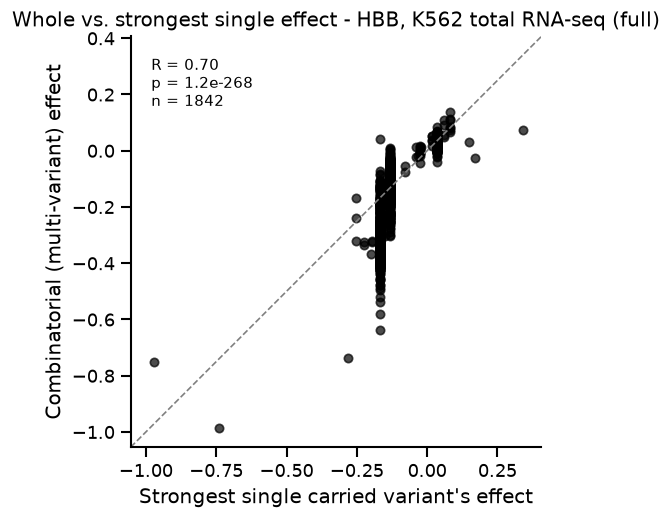

In [9]:
# Does the combinatorial effect track the single STRONGEST carried variant's own
# Atlas effect better than it tracks the SUM of all carried variants' effects? Same
# aspect-1/dashed-diagonal/Pearson-stats layout as the whole-vs-sum-of-parts figure
# above, for direct visual comparison.
x = combined["strongest_single_score"].to_numpy()
y = combined["whole_score"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
r, p = stats.pearsonr(x[mask], y[mask])
n = mask.sum()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x, y, s=25, color="black", alpha=0.7)

lo = min(x[mask].min(), y[mask].min())
hi = max(x[mask].max(), y[mask].max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Strongest single carried variant's effect")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title(f"Whole vs. strongest single effect - HBB, K562 total RNA-seq ({SCALE})")
ax.text(
    0.05, 0.95, f"R = {r:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
fig.tight_layout()

### Eyeballing the most extreme individuals

The 10 samples with the largest positive `diff` (whole >> sum, apparent synergy) and the 10 with the largest negative `diff` (whole << sum, apparent antagonism), with each of their carried variants' own single-variant score - to check by eye whether extreme samples share a common variant, are dominated by one strong effect, or look otherwise structured rather than just noisy.

In [10]:
def _variant_scores_table(variant_id):
    _, variants_1based = _variant_positions(variant_id)
    scores = [score_by_variant.get(v, np.nan) for v in variants_1based]
    order = np.argsort(-np.abs(scores))
    return [(variants_1based[i], scores[i]) for i in order]


extreme = pd.concat([
    combined.nlargest(10, "diff").assign(direction="synergy (whole > sum)"),
    combined.nsmallest(10, "diff").assign(direction="antagonism (whole < sum)"),
])[["sample", "direction", "diff", "whole_score", "sum_parts_score", "n_variants", "strongest_single_score"]]
display(extreme)

for _, row in extreme.iterrows():
    variant_id = combined.loc[combined["sample"] == row["sample"], "variant_id"].iloc[0]
    top_variants = _variant_scores_table(variant_id)[:5]
    print(f"{row['sample']} ({row['direction']}, diff={row['diff']:.3f}) - top carried variants by |score|:")
    for v, s in top_variants:
        print(f"    {v}: {s:.4f}")

,sample,direction,diff,whole_score,sum_parts_score,n_variants,strongest_single_score
98,HG00277,synergy (whole > sum),0.589701,-0.312045,-0.901746,2794,-0.166646
33,HG00150,synergy (whole > sum),0.547933,-0.357604,-0.905536,3352,-0.166646
765,HG01775,synergy (whole > sum),0.540868,-0.320102,-0.860970,3129,-0.166646
861,HG01918,synergy (whole > sum),0.534729,-0.007911,-0.542640,2573,-0.023794
6,HG00118,synergy (whole > sum),0.532013,-0.359578,-0.891591,2813,-0.166646
1067,HG03489,synergy (whole > sum),0.529346,-0.198494,-0.727840,3202,-0.166646
1413,HG04093,synergy (whole > sum),0.517242,-0.424784,-0.942027,3009,-0.166646
645,HG01529,synergy (whole > sum),0.506343,-0.340322,-0.846665,3493,-0.166646
628,HG01512,synergy (whole > sum),0.504800,-0.245924,-0.750724,3336,-0.166646
519,HG01308,synergy (whole > sum),0.493692,-0.438334,-0.932026,3130,-0.166646


HG00277 (synergy (whole > sum), diff=0.590) - top carried variants by |score|:
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5221273:A>G: -0.0246
    chr11:4740466:A>G: -0.0187
HG00150 (synergy (whole > sum), diff=0.548) - top carried variants by |score|:
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5284841:T>C: -0.0931
    chr11:5239228:T>C: 0.0345
HG01775 (synergy (whole > sum), diff=0.541) - top carried variants by |score|:
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5284841:T>C: -0.0931
    chr11:5239228:T>C: 0.0345
HG01918 (synergy (whole > sum), diff=0.535) - top carried variants by |score|:
    chr11:5367672:G>C: -0.0238
    chr11:5498240:C>T: 0.0177
    chr11:4734635:A>G: -0.0166
    chr11:5480295:T>C: 0.0162
    chr11:5343750:A>C: -0.0154
HG00118 (synergy (whole > sum), diff=0.532) - top carried variants b

### Model dissection: is this saturation, or genuine sequence-context computation?

Reframing `diff = whole_score - sum_parts_score` as an *interaction residual* `R = f(x + v_1 + ... + v_n) - f(x) - sum_i(f(x + v_i) - f(x))`: a consistent `R < 0` means AlphaGenome's combined predictions are systematically smaller than the additive null - subadditive integration of sequence perturbations, not necessarily anything biological.

One confound to rule out first: a purely *output-side* saturating nonlinearity (some monotonic squashing function applied to an otherwise-additive latent score) would produce the exact same subadditive `R` with no genuine sequence-context computation behind it at all - and critically, that kind of squashing shouldn't care whether the contributing variants are 20bp or 200kb apart, since it only ever sees their summed latent effect. The clustering result above (`|diff|` vs. median nearest-neighbor distance, R = -0.08) is already evidence against pure saturation: more spatially clustered variants show *larger* deviation from additive, which a distance-blind output squash can't explain - it points toward real local sequence-context interaction instead.

A second, more direct saturation probe: instead of the signed `diff` (which can hide saturation by cancelling across samples with opposite-sign sums), take the **difference of the absolutes**, `|whole_score| - |sum_parts_score|`. Pure output saturation predicts this goes more negative as `|sum_parts_score|` grows (the model's combined output can't reach as extreme a value as the sum of magnitudes would suggest); no such trend would argue against a simple squashing explanation.

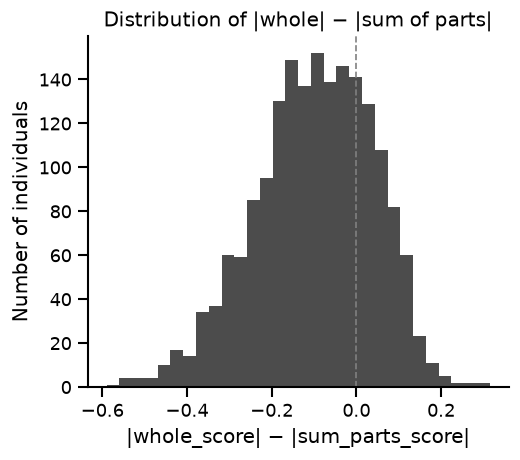

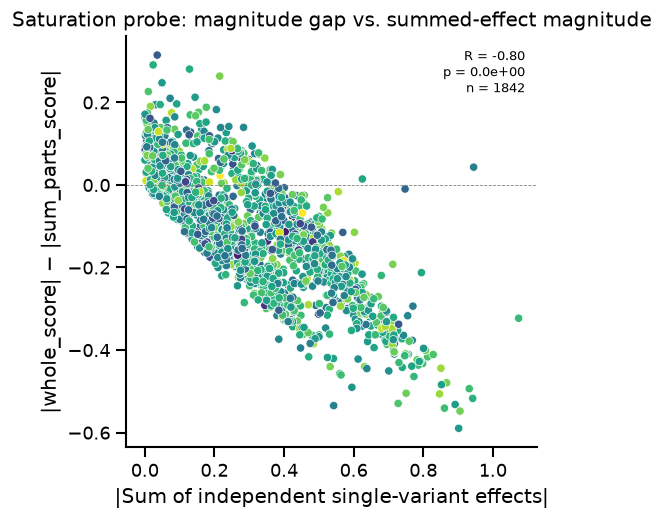

In [11]:
combined["abs_mag_diff"] = combined["whole_score"].abs() - combined["sum_parts_score"].abs()

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hist(combined["abs_mag_diff"], bins=30, color="black", alpha=0.7)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("|whole_score| − |sum_parts_score|")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of |whole| − |sum of parts|")
fig.tight_layout()


fig, ax = plt.subplots(figsize=(4.5, 4.5))
sns.scatterplot(
    data=combined, x=combined["sum_parts_score"].abs(), y="abs_mag_diff",
    hue="n_variants", palette="viridis", s=25, ax=ax, legend=False,
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
_annotate_corr(ax, combined["sum_parts_score"].abs().to_numpy(), combined["abs_mag_diff"].to_numpy())
ax.set_xlabel("|Sum of independent single-variant effects|")
ax.set_ylabel("|whole_score| − |sum_parts_score|")
ax.set_title("Saturation probe: magnitude gap vs. summed-effect magnitude")
fig.tight_layout()

The same four per-sample summaries (burden, allele frequency, distance to TSS, clustering), now against the magnitude-gap measure (`|whole| - |sum of parts|`) instead of `|diff|`, since that's the one that actually showed a strong effect above.

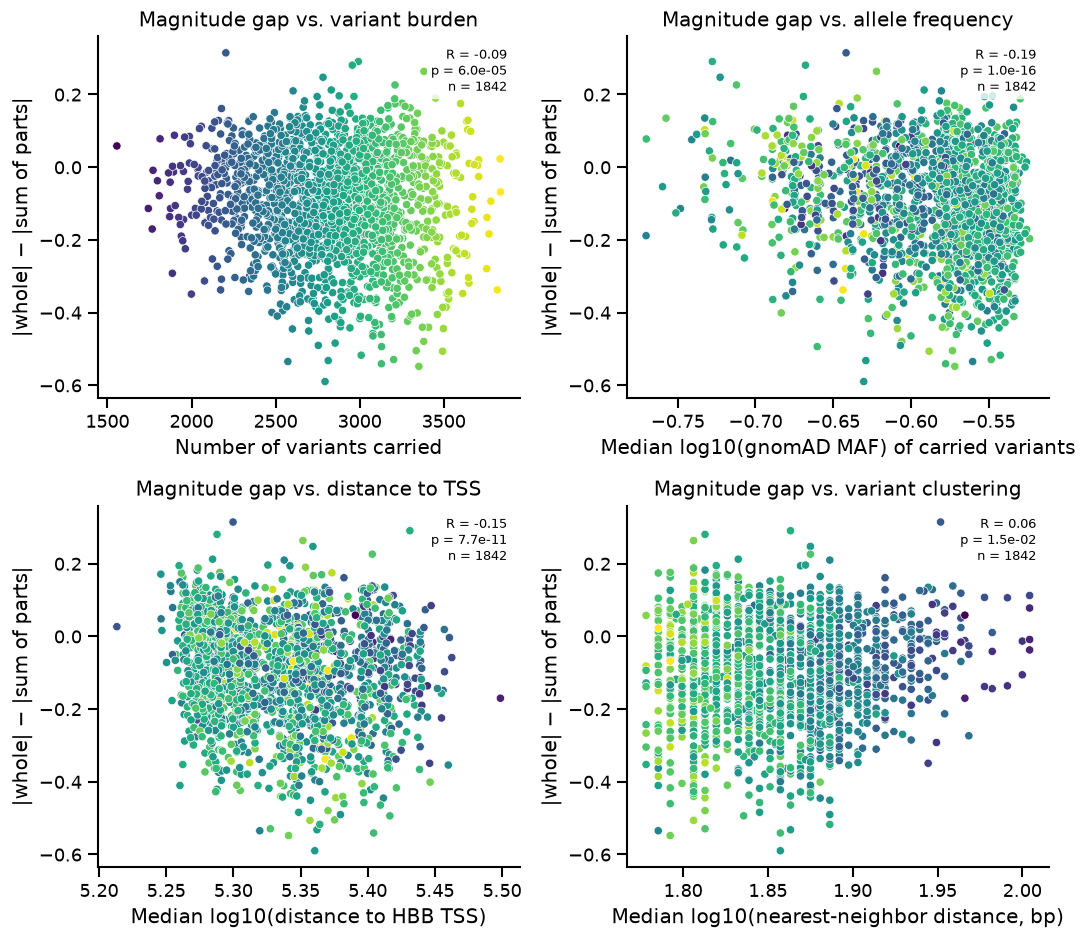

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (col, xlabel, title) in zip(axes.flat, panels):
    sns.scatterplot(
        data=combined, x=col, y="abs_mag_diff", hue="n_variants",
        palette="viridis", s=25, ax=ax, legend=False,
    )
    _annotate_corr(ax, combined[col].to_numpy(), combined["abs_mag_diff"].to_numpy())
    ax.set_xlabel(xlabel)
    ax.set_ylabel("|whole| − |sum of parts|")
    ax.set_title(title.replace("Deviation magnitude", "Magnitude gap"))
fig.tight_layout()

### How many single-variant effects does it take to reach the combinatorial effect?

For each sample, take the subset of their carried variants with both a matched Atlas score and a gnomAD MAF (so orderings below are directly comparable - same variants, just reordered), sort that subset three ways - strongest single effect first, closest to the HBB TSS first, rarest (lowest MAF) first - and cumulatively sum each ordering's *signed* scores until the running sum's magnitude reaches `|whole_score|`. `k_*` is how many variants that took under each ordering; fewer needed means that ordering is more 'efficient' at explaining the combined effect on its own. The three orderings share the same variant subset, so the running sum after *all* of them is identical regardless of order - `reached` (whether that final sum's magnitude actually clears `|whole_score|`, i.e. whether synergy makes the target unreachable at all) is therefore the same true/false for all three `k_*` in a given sample, only restricted to samples where it's True below.

In [13]:
def _count_to_reach(scores, sort_values, ascending, target_abs):
    order = np.argsort(sort_values) if ascending else np.argsort(-sort_values)
    cumsum = np.cumsum(scores[order])
    hit = np.flatnonzero(np.abs(cumsum) >= target_abs)
    return int(hit[0]) + 1 if hit.size else None


def _sample_k_summary(row):
    positions, variants_1based = _variant_positions(row["variant_id"])
    scores = np.array([score_by_variant.get(v, np.nan) for v in variants_1based])
    mafs = np.array([maf_by_variant.get(v, np.nan) for v in variants_1based])
    positions = np.array(positions, dtype=float)
    mask = np.isfinite(scores) & np.isfinite(mafs)
    scores, mafs, positions = scores[mask], mafs[mask], positions[mask]
    if len(scores) == 0:
        return pd.Series({
            "k_score": np.nan, "k_distance_tss": np.nan, "k_maf": np.nan,
            "n_variants_used": 0, "reached": False,
        })
    target = abs(row["whole_score"])
    dist_tss = np.abs(positions - tss)
    k_score = _count_to_reach(scores, np.abs(scores), ascending=False, target_abs=target)
    k_distance = _count_to_reach(scores, dist_tss, ascending=True, target_abs=target)
    k_maf = _count_to_reach(scores, mafs, ascending=True, target_abs=target)
    return pd.Series({
        "k_score": k_score, "k_distance_tss": k_distance, "k_maf": k_maf,
        "n_variants_used": len(scores), "reached": k_score is not None,
    })

combined = combined.join(combined.apply(_sample_k_summary, axis=1))
print(f"{int(combined['reached'].sum())} / {len(combined)} samples reach |whole_score| "
      "with their matched-variant subset's total sum")
combined.loc[combined["reached"], ["n_variants_used", "k_score", "k_distance_tss", "k_maf"]].describe()

1828 / 1842 samples reach |whole_score| with their matched-variant subset's total sum


,n_variants_used,k_score,k_distance_tss,k_maf
count,1828.000000,1828.000000,1777.000000,1788.000000
mean,2828.081510,13.315098,377.101857,715.091163
std,374.465426,86.302508,658.903926,469.746799
min,1556.000000,1.000000,1.000000,1.000000
25%,2570.000000,1.000000,9.000000,401.000000
50%,2844.500000,2.000000,19.000000,778.500000
75%,3090.250000,3.000000,383.000000,949.250000
max,3836.000000,1720.000000,3458.000000,3727.000000


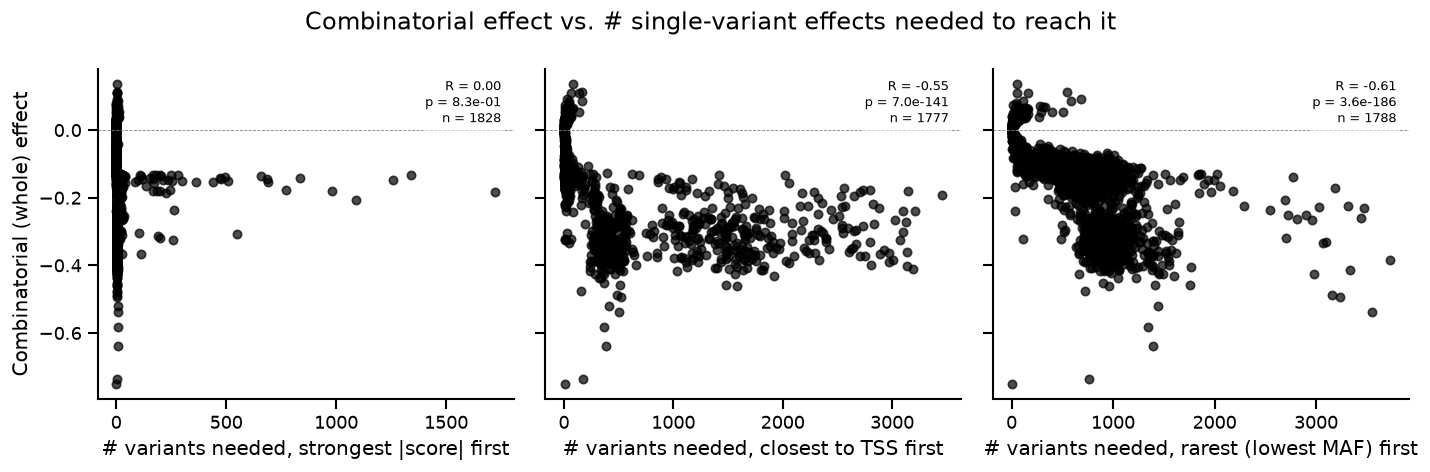

In [14]:
reached = combined[combined["reached"]]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
kpanels = [
    ("k_score", "# variants needed, strongest |score| first"),
    ("k_distance_tss", "# variants needed, closest to TSS first"),
    ("k_maf", "# variants needed, rarest (lowest MAF) first"),
]
for ax, (col, xlabel) in zip(axes, kpanels):
    ax.scatter(reached[col], reached["whole_score"], s=25, color="black", alpha=0.7)
    _annotate_corr(ax, reached[col].to_numpy(), reached["whole_score"].to_numpy())
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("Combinatorial (whole) effect")
fig.suptitle("Combinatorial effect vs. # single-variant effects needed to reach it")
fig.tight_layout()

Same three orderings, but normalized: `k / n_variants_used` as a percentage, so samples with very different total variant counts are directly comparable (a k of 2 means something different for a sample with 1600 variants vs. one with 3800).

In [15]:
reached["k_score_pct"] = 100 * reached["k_score"] / reached["n_variants_used"]
reached["k_distance_tss_pct"] = 100 * reached["k_distance_tss"] / reached["n_variants_used"]
reached["k_maf_pct"] = 100 * reached["k_maf"] / reached["n_variants_used"]
reached[["k_score_pct", "k_distance_tss_pct", "k_maf_pct"]].describe()

/tmp/28402528/ipykernel_3281180/985673211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reached["k_score_pct"] = 100 * reached["k_score"] / reached["n_variants_used"]
/tmp/28402528/ipykernel_3281180/985673211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reached["k_distance_tss_pct"] = 100 * reached["k_distance_tss"] / reached["n_variants_used"]
/tmp/28402528/ipykernel_3281180/985673211.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

,k_score_pct,k_distance_tss_pct,k_maf_pct
count,1828.000000,1777.000000,1788.000000
mean,0.496070,13.066851,25.280275
std,3.257550,22.202878,15.582226
min,0.026991,0.027278,0.027278
25%,0.036748,0.315831,14.076741
50%,0.071556,0.597270,28.524056
75%,0.114602,14.162806,34.445964
max,73.191489,98.346790,99.942496


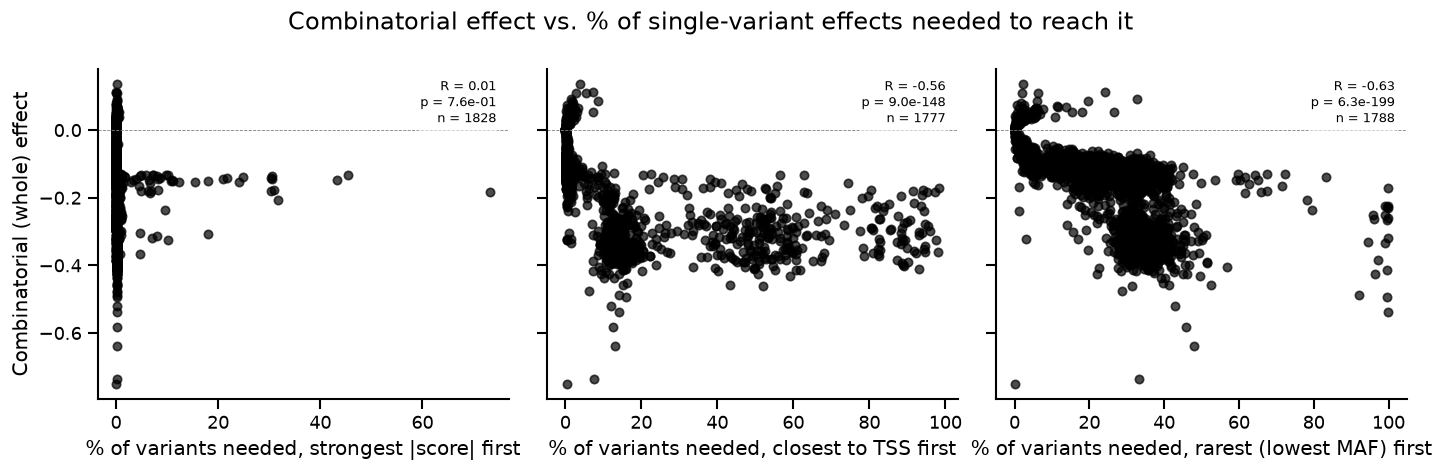

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
kpanels_pct = [
    ("k_score_pct", "% of variants needed, strongest |score| first"),
    ("k_distance_tss_pct", "% of variants needed, closest to TSS first"),
    ("k_maf_pct", "% of variants needed, rarest (lowest MAF) first"),
]
for ax, (col, xlabel) in zip(axes, kpanels_pct):
    ax.scatter(reached[col], reached["whole_score"], s=25, color="black", alpha=0.7)
    _annotate_corr(ax, reached[col].to_numpy(), reached["whole_score"].to_numpy())
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("Combinatorial (whole) effect")
fig.suptitle("Combinatorial effect vs. % of single-variant effects needed to reach it")
fig.tight_layout()

### Control: what if we sort the other way?

Reversed orderings - weakest `|score|` first, farthest from the TSS first, most common (highest MAF) first - as a sanity check on the result above: if these need almost every variant to reach the same target while the forward orderings needed only a handful, that confirms a real asymmetry (a few variants dominate) rather than an artifact of how `k` is counted.

In [17]:
def _sample_k_summary_reversed(row):
    positions, variants_1based = _variant_positions(row["variant_id"])
    scores = np.array([score_by_variant.get(v, np.nan) for v in variants_1based])
    mafs = np.array([maf_by_variant.get(v, np.nan) for v in variants_1based])
    positions = np.array(positions, dtype=float)
    mask = np.isfinite(scores) & np.isfinite(mafs)
    scores, mafs, positions = scores[mask], mafs[mask], positions[mask]
    if len(scores) == 0:
        return pd.Series({"k_score_rev": np.nan, "k_distance_tss_rev": np.nan, "k_maf_rev": np.nan})
    target = abs(row["whole_score"])
    dist_tss = np.abs(positions - tss)
    return pd.Series({
        "k_score_rev": _count_to_reach(scores, np.abs(scores), ascending=True, target_abs=target),
        "k_distance_tss_rev": _count_to_reach(scores, dist_tss, ascending=False, target_abs=target),
        "k_maf_rev": _count_to_reach(scores, mafs, ascending=False, target_abs=target),
    })

combined = combined.join(combined.apply(_sample_k_summary_reversed, axis=1))
reached = combined[combined["reached"]].copy()
reached["k_score_rev_pct"] = 100 * reached["k_score_rev"] / reached["n_variants_used"]
reached["k_distance_tss_rev_pct"] = 100 * reached["k_distance_tss_rev"] / reached["n_variants_used"]
reached["k_maf_rev_pct"] = 100 * reached["k_maf_rev"] / reached["n_variants_used"]
reached[["k_score_rev", "k_distance_tss_rev", "k_maf_rev"]].describe()

,k_score_rev,k_distance_tss_rev,k_maf_rev
count,1687.000000,1759.000000,1800.000000
mean,1985.934795,1048.536100,751.902778
std,754.227170,884.378698,839.165292
min,19.000000,1.000000,1.000000
25%,1467.000000,291.000000,124.000000
50%,1957.000000,725.000000,254.000000
75%,2582.000000,1756.000000,1625.750000
max,3836.000000,3544.000000,3404.000000


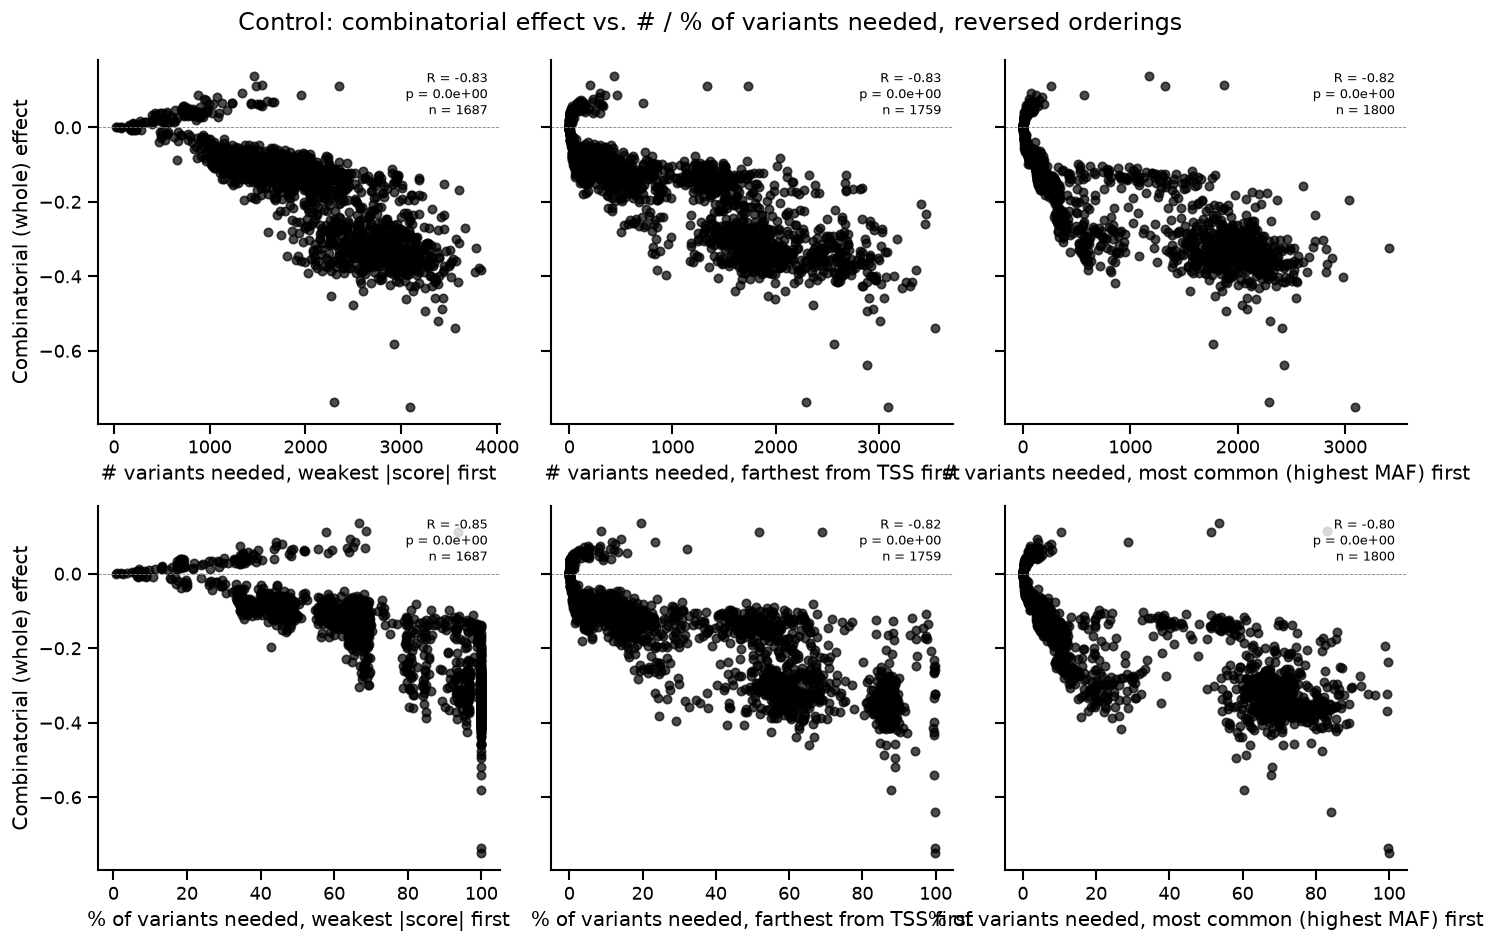

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey="row")
row_specs = [
    ("k_score_rev", "k_distance_tss_rev", "k_maf_rev", "# variants needed"),
    ("k_score_rev_pct", "k_distance_tss_rev_pct", "k_maf_rev_pct", "% of variants needed"),
]
titles = ["weakest |score| first", "farthest from TSS first", "most common (highest MAF) first"]
for row_idx, (col_score, col_dist, col_maf, ylabel_suffix) in enumerate(row_specs):
    for ax, col, title in zip(axes[row_idx], (col_score, col_dist, col_maf), titles):
        ax.scatter(reached[col], reached["whole_score"], s=25, color="black", alpha=0.7)
        _annotate_corr(ax, reached[col].to_numpy(), reached["whole_score"].to_numpy())
        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.set_xlabel(f"{ylabel_suffix}, {title}")
    axes[row_idx, 0].set_ylabel("Combinatorial (whole) effect")
fig.suptitle("Control: combinatorial effect vs. # / % of variants needed, reversed orderings")
fig.tight_layout()

### Lowest-first vs. highest-first: how much do the two directions disagree?

For each criterion, the % of variants needed sorting lowest-first (weakest `|score|`, closest to the TSS, lowest MAF) against the % needed sorting highest-first (strongest `|score|`, farthest from the TSS, highest MAF) - same sample, same target, opposite order. Points far from the diagonal are samples where direction matters a lot; the closer to the diagonal, the less the ordering criterion actually mattered for that sample.

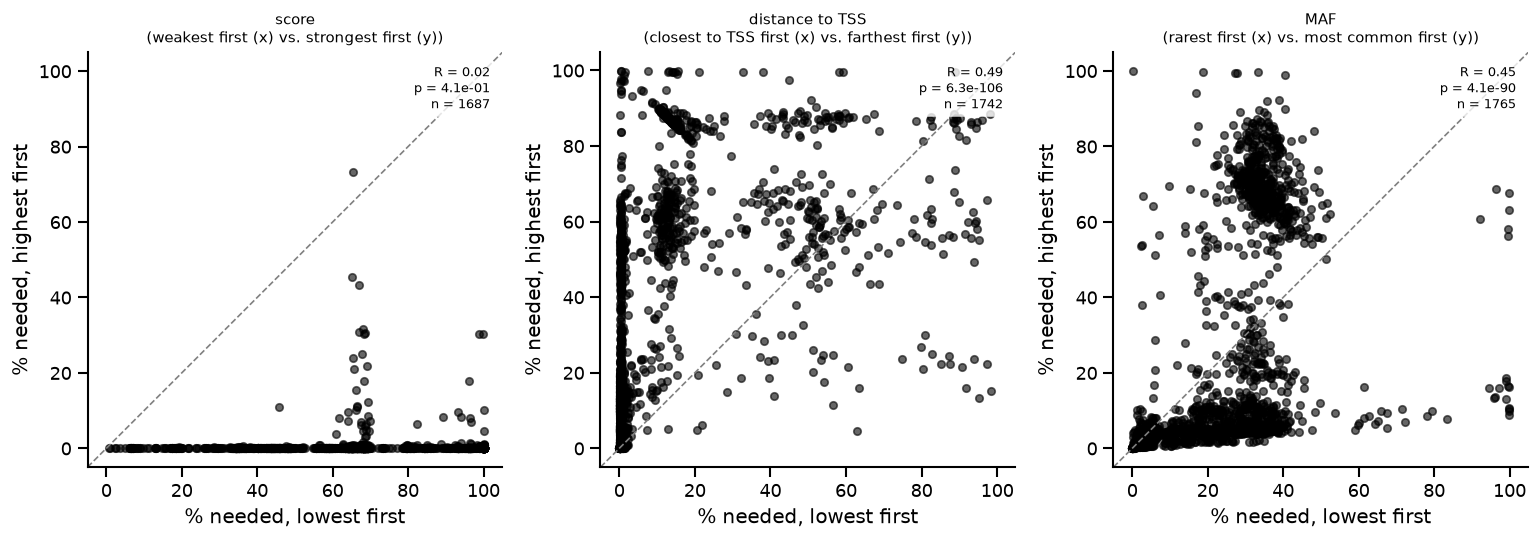

In [19]:
reached["k_score_pct"] = 100 * reached["k_score"] / reached["n_variants_used"]
reached["k_distance_tss_pct"] = 100 * reached["k_distance_tss"] / reached["n_variants_used"]
reached["k_maf_pct"] = 100 * reached["k_maf"] / reached["n_variants_used"]

lowest_vs_highest = [
    ("k_score_rev_pct", "k_score_pct", "weakest first (x) vs. strongest first (y)", "score"),
    ("k_distance_tss_pct", "k_distance_tss_rev_pct", "closest to TSS first (x) vs. farthest first (y)", "distance to TSS"),
    ("k_maf_pct", "k_maf_rev_pct", "rarest first (x) vs. most common first (y)", "MAF"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (xcol, ycol, subtitle, criterion) in zip(axes, lowest_vs_highest):
    x = reached[xcol].to_numpy()
    y = reached[ycol].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x, y, s=20, color="black", alpha=0.6)

    lo, hi = 0, max(x[mask].max(), y[mask].max())
    pad = 0.05 * hi if hi > 0 else 1.0
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", adjustable="box")

    _annotate_corr(ax, x, y)
    ax.set_xlabel("% needed, lowest first")
    ax.set_ylabel("% needed, highest first")
    ax.set_title(f"{criterion}\n({subtitle})", fontsize=9)
fig.tight_layout()

### Clustering individuals by their combinatorial effect

`whole_score` itself turned out to be multimodal (visible as the horizontal bands in the very first whole-vs-sum scatter, and the source of the bimodal MAF-ordering result above) - most plausibly discrete genotype states at a handful of common, high-effect sites in this window (population/LD structure), not noise. A 3-component Gaussian mixture on `whole_score` alone formalizes that into three individual clusters, ordered by increasing mean `whole_score` (cluster 0 = most negative/antagonistic mode).

In [20]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
raw_labels = gmm.fit_predict(combined[["whole_score"]].to_numpy())

cluster_order = (
    pd.Series(combined["whole_score"].to_numpy())
    .groupby(raw_labels).mean().sort_values().index
)
label_map = {old: new for new, old in enumerate(cluster_order)}
combined["cluster"] = pd.Categorical([label_map[l] for l in raw_labels])

combined.groupby("cluster", observed=True)["whole_score"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
cluster,,,,,
0,712,-0.322386,0.068378,-0.987787,-0.192918
1,979,-0.115654,0.033501,-0.191808,-0.032367
2,151,0.026064,0.032232,-0.031514,0.136587


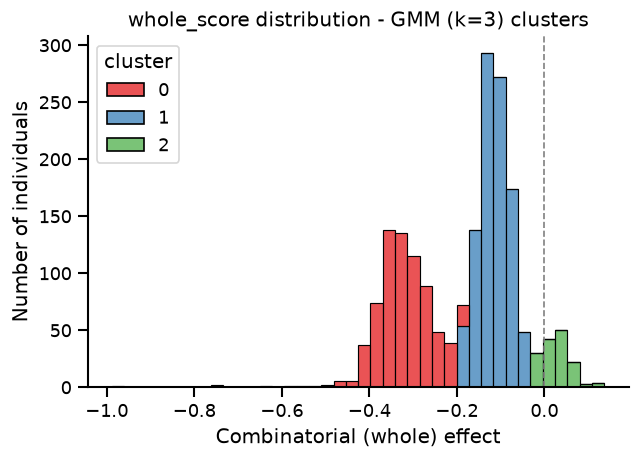

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.histplot(
    data=combined, x="whole_score", hue="cluster", bins=40,
    palette="Set1", multiple="stack", ax=ax,
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Combinatorial (whole) effect")
ax.set_ylabel("Number of individuals")
ax.set_title("whole_score distribution - GMM (k=3) clusters")
fig.tight_layout()

### Variants carried by each cluster

For each cluster, the union of variants actually carried by any individual assigned to it (restricted, as elsewhere, to variants with a matched Atlas score), then the same single-variant diagnostics as at the top of this notebook, faceted by cluster.

In [22]:
cluster_variants = {}
for c in sorted(combined["cluster"].cat.categories):
    variant_set = set()
    for variant_id in combined.loc[combined["cluster"] == c, "variant_id"]:
        _, v1based = _variant_positions(variant_id)
        variant_set.update(v1based)
    cluster_variants[c] = variant_set
    n_samples = int((combined["cluster"] == c).sum())
    print(f"cluster {c}: {n_samples} individuals, {len(variant_set)} unique carried variants")

frames = []
for c, vset in cluster_variants.items():
    sub = singles[singles["variant"].isin(vset)].copy()
    sub["cluster"] = c
    frames.append(sub)
singles_by_cluster = pd.concat(frames, ignore_index=True)
singles_by_cluster_maf = singles_by_cluster.merge(maf, on="variant", how="inner")
singles_by_cluster_maf["log10_maf"] = np.log10(singles_by_cluster_maf["gnomad_maf"])
singles_by_cluster_maf["log10_dist_tss"] = np.log10(
    np.where(singles_by_cluster_maf["position"] == tss, 1, np.abs(singles_by_cluster_maf["position"] - tss))
)
len(singles_by_cluster), len(singles_by_cluster_maf)

cluster 0: 712 individuals, 24867 unique carried variants


cluster 1: 979 individuals, 27192 unique carried variants
cluster 2: 151 individuals, 13728 unique carried variants


/users/diasfrazer/manglada/miniforge3/envs/wihttsoip/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(65787, 65787)

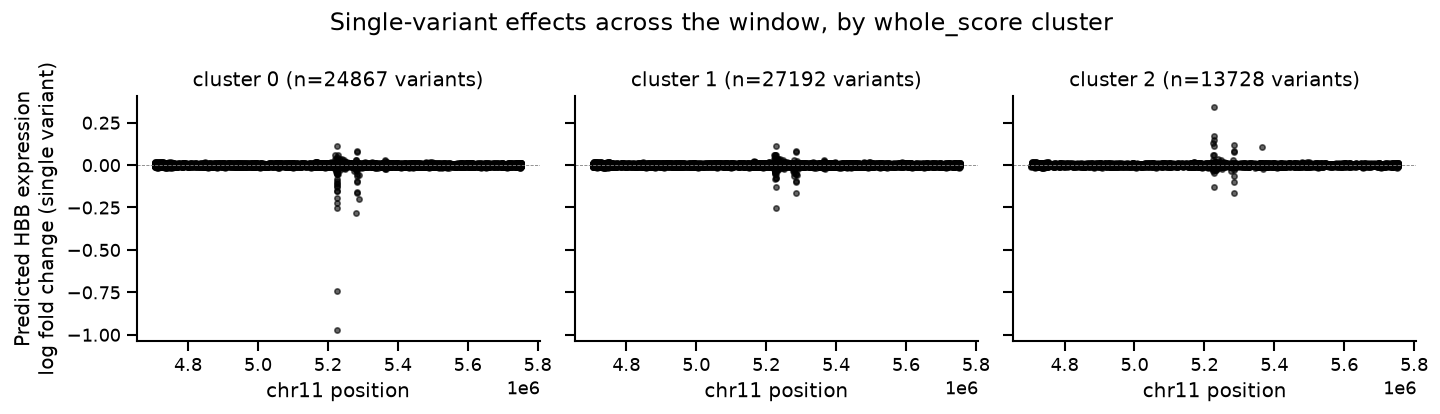

In [23]:
clusters = sorted(combined["cluster"].cat.categories)
fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 3.5), sharex=True, sharey=True)
for ax, c in zip(axes, clusters):
    sub = singles_by_cluster[singles_by_cluster["cluster"] == c]
    ax.scatter(sub["position"], sub["score"], s=10, color="black", alpha=0.6)
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel(f"{CHROMOSOME} position")
    ax.set_title(f"cluster {c} (n={len(sub)} variants)")
axes[0].set_ylabel("Predicted HBB expression\nlog fold change (single variant)")
fig.suptitle("Single-variant effects across the window, by whole_score cluster")
fig.tight_layout()

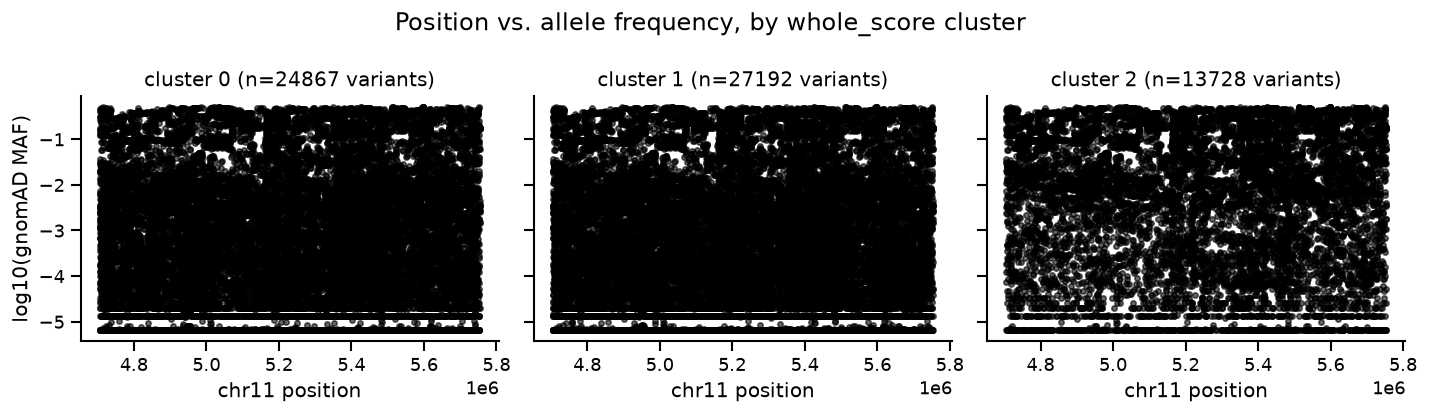

In [24]:
fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 3.5), sharex=True, sharey=True)
for ax, c in zip(axes, clusters):
    sub = singles_by_cluster_maf[singles_by_cluster_maf["cluster"] == c]
    ax.scatter(sub["position"], sub["log10_maf"], s=10, color="black", alpha=0.6)
    ax.set_xlabel(f"{CHROMOSOME} position")
    ax.set_title(f"cluster {c} (n={len(sub)} variants)")
axes[0].set_ylabel("log10(gnomAD MAF)")
fig.suptitle("Position vs. allele frequency, by whole_score cluster")
fig.tight_layout()

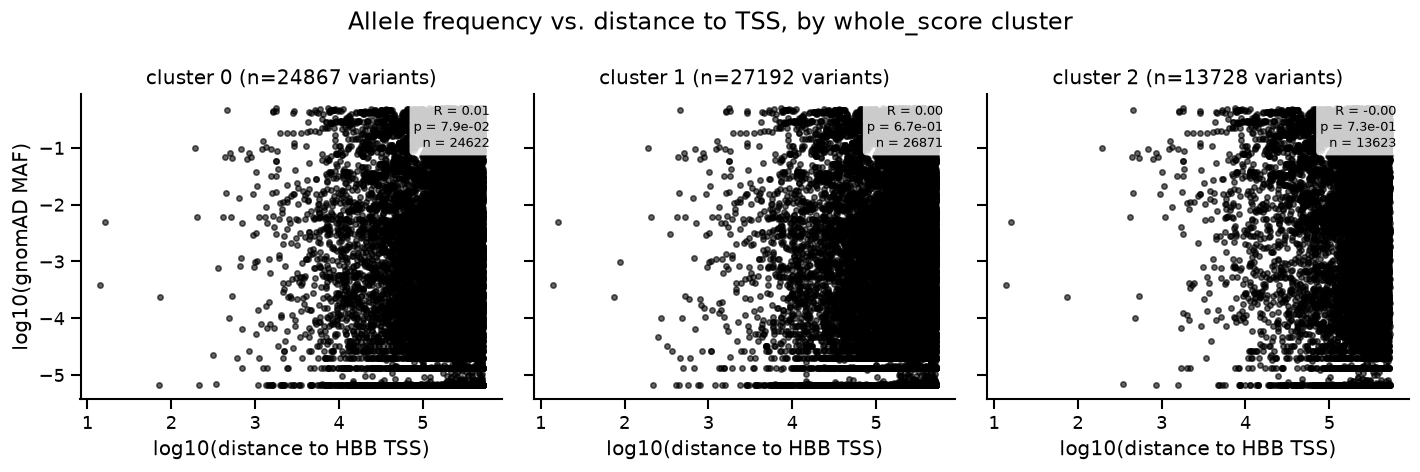

In [25]:
fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 4), sharex=True, sharey=True)
for ax, c in zip(axes, clusters):
    sub = singles_by_cluster_maf[singles_by_cluster_maf["cluster"] == c]
    ax.scatter(sub["log10_dist_tss"], sub["log10_maf"], s=10, color="black", alpha=0.6)
    _annotate_corr(ax, sub["log10_dist_tss"].to_numpy(), sub["log10_maf"].to_numpy())
    ax.set_xlabel("log10(distance to HBB TSS)")
    ax.set_title(f"cluster {c} (n={len(sub)} variants)")
axes[0].set_ylabel("log10(gnomAD MAF)")
fig.suptitle("Allele frequency vs. distance to TSS, by whole_score cluster")
fig.tight_layout()